# 09 Kinematics: Velocity and Acceleration

Differentiation and integration depend on the param coordinate and on the kinematic family being transformed.


## Imports

Imports are kept separate so the instructional cells can focus on TAL semantics.


In [1]:
import matplotlib.pyplot as plt
from IPython.display import display
import pandas as pd
import tal.spatial as spatial
from tal.spatial import LinearAcceleration
from tal.spatial.temporal.options import (
    KinematicsDerivativeOptions,
    KinematicsIntegralOptions,
    KinematicsSmoothingOptions,
)

from pathlib import Path
import sys

_release_dir = Path.cwd()
if not (_release_dir / '_helpers.py').exists():
    candidate = Path.cwd() / 'examples' / 'release'
    if candidate.exists():
        _release_dir = candidate
if str(_release_dir) not in sys.path:
    sys.path.append(str(_release_dir))

from _helpers import (
    build_framegraph_spatial_payloads,
    build_topology_edge_payloads,
    compact_dataset,
    display_result,
    explain_expected_failure,
    make_imu_gps_alignment_aos,
    make_kinematics_demo_objects,
    make_pose_demo_objects,
    show_ao,
    summarize_ao,
)


## Setup: position, linear velocity, angular velocity

The objects share a `time_s` coordinate so temporal calculus has a physical domain.


In [2]:
t, position, lv, av, vel = make_kinematics_demo_objects()

display_result(
    'Kinematics inputs',
    pd.DataFrame(
        [
            {'object': 'Position', 'dims': dict(position.unsafe_data.sizes), 'vars': list(position.unsafe_data.data_vars)},
            {'object': 'LinearVelocity', 'dims': dict(lv.unsafe_data.sizes), 'vars': list(lv.unsafe_data.data_vars)},
            {'object': 'AngularVelocity', 'dims': dict(av.unsafe_data.sizes), 'vars': list(av.unsafe_data.data_vars)},
        ]
    ),
)


#### Kinematics inputs

,object,dims,vars
0,Position,"{'sample': 11, 'axis': 3}",[position]
1,LinearVelocity,"{'sample': 11, 'axis': 3}",[position]
2,AngularVelocity,"{'sample': 11, 'angular_axis': 3}",[angular_velocity]


,object,dims,vars
0,Position,"{'sample': 11, 'axis': 3}",[position]
1,LinearVelocity,"{'sample': 11, 'axis': 3}",[position]
2,AngularVelocity,"{'sample': 11, 'angular_axis': 3}",[angular_velocity]


## Combined velocity and temporal operations

Combined velocity can be represented as vector6 or as linear/angular components. Smoothing and integration preserve kinematic structure.


In [3]:
vel_v6 = vel.as_vector6(validate=True)
vel_components = vel_v6.as_components(validate=True)
acc_family = vel.differentiate(on='time_s', validate=True)
vel_smoothed = vel.smooth(
    on='time_s',
    opts=KinematicsSmoothingOptions(method='moving_average', window=5),
    validate=True,
)
vel_from_acc = acc_family.integrate(
    on='time_s',
    opts=KinematicsIntegralOptions(method='cumulative_trapezoid', initial_value=0.0),
    validate=True,
)

display(
    pd.DataFrame(
        [
            {'result': 'Velocity.as_vector6()', 'type': type(vel_v6).__name__, 'dims': dict(vel_v6.unsafe_data.sizes)},
            {'result': 'as_components()', 'type': type(vel_components).__name__, 'dims': dict(vel_components.unsafe_data.sizes)},
            {'result': 'differentiate()', 'type': type(acc_family).__name__, 'dims': dict(acc_family.unsafe_data.sizes)},
            {'result': 'smooth()', 'type': type(vel_smoothed).__name__, 'dims': dict(vel_smoothed.unsafe_data.sizes)},
            {'result': 'integrate()', 'type': type(vel_from_acc).__name__, 'dims': dict(vel_from_acc.unsafe_data.sizes)},
        ]
    )
)


,result,type,dims
0,Velocity.as_vector6(),Velocity,"{'sample': 11, 'velocity_axis': 6}"
1,as_components(),Velocity,"{'sample': 11, 'linear_axis': 3, 'angular_axis..."
2,differentiate(),Acceleration,"{'sample': 11, 'axis': 3, 'angular_axis': 3}"
3,smooth(),Velocity,"{'sample': 11, 'axis': 3, 'angular_axis': 3}"
4,integrate(),Velocity,"{'sample': 11, 'axis': 3, 'angular_axis': 3}"


## Visual calculus chain

Differentiate position to velocity, then velocity to acceleration, and inspect the result in time.


#### Differentiation chain outputs

,result,type,dims
0,position.differentiate(),LinearVelocity,"{'sample': 11, 'axis': 3}"
1,velocity.differentiate(),LinearAcceleration,"{'sample': 11, 'axis': 3}"


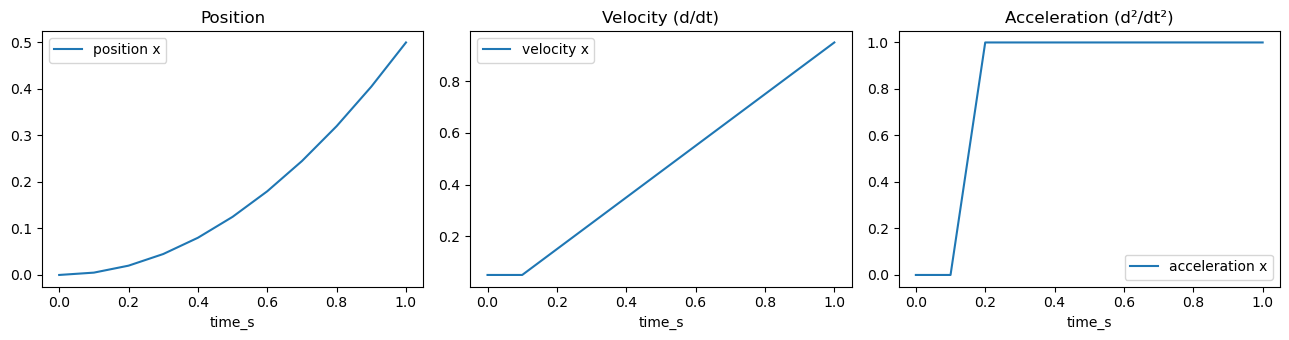

In [4]:
pos_vel = position.differentiate(on='time_s', validate=True)
pos_acc = pos_vel.differentiate(on='time_s', validate=True)

display_result(
    'Differentiation chain outputs',
    pd.DataFrame(
        [
            {'result': 'position.differentiate()', 'type': type(pos_vel).__name__, 'dims': dict(pos_vel.unsafe_data.sizes)},
            {'result': 'velocity.differentiate()', 'type': type(pos_acc).__name__, 'dims': dict(pos_acc.unsafe_data.sizes)},
        ]
    ),
)

def _x_component(da):
    comp_dims = [d for d in da.dims if d not in {'sample', 'trial'}]
    if not comp_dims:
        return da
    dim = comp_dims[0]
    labels = da.coords[dim].values if dim in da.coords else []
    if len(labels) and 'x' in [str(v) for v in labels]:
        return da.sel({dim: 'x'})
    if len(labels):
        return da.sel({dim: labels[0]})
    return da.isel({dim: 0})

pos_var = next(iter(position.unsafe_data.data_vars))
vel_var = next(iter(pos_vel.unsafe_data.data_vars))
acc_var = next(iter(pos_acc.unsafe_data.data_vars))

fig, axes = plt.subplots(1, 3, figsize=(13, 3.5), sharex=True)
axes[0].plot(position.unsafe_data['time_s'].values, _x_component(position.unsafe_data[pos_var]).values, label='position x')
axes[1].plot(pos_vel.unsafe_data['time_s'].values, _x_component(pos_vel.unsafe_data[vel_var]).values, label='velocity x')
axes[2].plot(pos_acc.unsafe_data['time_s'].values, _x_component(pos_acc.unsafe_data[acc_var]).values, label='acceleration x')

axes[0].set_title('Position')
axes[1].set_title('Velocity (d/dt)')
axes[2].set_title('Acceleration (d²/dt²)')
for ax in axes:
    ax.set_xlabel('time_s')
    ax.legend(loc='best')

fig.tight_layout()


## Robust temporal operators

Options classes belong inside the method calls that consume them. This keeps derivative, smoothing, and integration policy explicit.


#### Derivative, integral, and smoothing outputs

,result,type,dims
0,differentiate(local_poly),LinearAcceleration,"{'sample': 11, 'axis': 3}"
1,integrate(simpson),LinearVelocity,"{'sample': 11, 'axis': 3}"
2,smooth(gaussian),LinearVelocity,"{'sample': 11, 'axis': 3}"


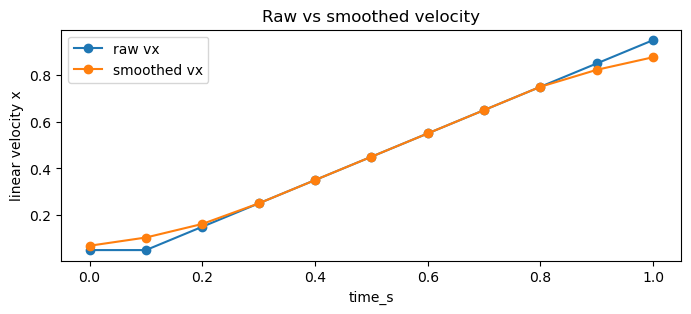

In [5]:
lin_acc = lv.differentiate(
    on='time_s',
    opts=KinematicsDerivativeOptions(method='local_poly', order=1, window=5, poly_order=2, edge_mode='partial_renorm'),
    validate=True,
)
lin_vel_rt = lin_acc.integrate(
    on='time_s',
    opts=KinematicsIntegralOptions(method='simpson', initial_value=0.0),
    validate=True,
)
lv_gauss = lv.smooth(
    on='time_s',
    opts=KinematicsSmoothingOptions(method='gaussian', sigma=0.15, window=5),
    validate=True,
)

display_result(
    'Derivative, integral, and smoothing outputs',
    pd.DataFrame(
        [
            {'result': 'differentiate(local_poly)', 'type': type(lin_acc).__name__, 'dims': dict(lin_acc.unsafe_data.sizes)},
            {'result': 'integrate(simpson)', 'type': type(lin_vel_rt).__name__, 'dims': dict(lin_vel_rt.unsafe_data.sizes)},
            {'result': 'smooth(gaussian)', 'type': type(lv_gauss).__name__, 'dims': dict(lv_gauss.unsafe_data.sizes)},
        ]
    ),
)

lv_var = next(iter(lv.unsafe_data.data_vars))
lv_gauss_var = next(iter(lv_gauss.unsafe_data.data_vars))

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(t, lv.unsafe_data[lv_var].sel(axis='x'), marker='o', label='raw vx')
ax.plot(t, lv_gauss.unsafe_data[lv_gauss_var].sel(axis='x'), marker='o', label='smoothed vx')
ax.set(title='Raw vs smoothed velocity', xlabel='time_s', ylabel='linear velocity x')
ax.legend(loc='best')


## Functional API vs typed method

Typed inputs let TAL choose typed outputs. Dataset inputs can return a generic AO when requested.


In [6]:
ao_default = spatial.differentiate(
    lv.unsafe_data,
    kind='linear_velocity',
    on='time_s',
    target_cls=None,
    validate=True,
)
typed_acc = spatial.differentiate(
    lv,
    kind='linear_velocity',
    on='time_s',
    target_cls=LinearAcceleration,
    validate=True,
)

display_result(
    'Functional differentiation return types',
    pd.DataFrame(
        [
            {'call': 'spatial.differentiate(dataset, target_cls=None)', 'type': type(ao_default).__name__, 'dims': dict(ao_default.unsafe_data.sizes)},
            {'call': 'spatial.differentiate(lv, target_cls=LinearAcceleration)', 'type': type(typed_acc).__name__, 'dims': dict(typed_acc.unsafe_data.sizes)},
        ]
    ),
)


#### Functional differentiation return types

,call,type,dims
0,"spatial.differentiate(dataset, target_cls=None)",AnalysisObject,"{'sample': 11, 'axis': 3}"
1,"spatial.differentiate(lv, target_cls=LinearAcc...",LinearAcceleration,"{'sample': 11, 'axis': 3}"


,call,type,dims
0,"spatial.differentiate(dataset, target_cls=None)",AnalysisObject,"{'sample': 11, 'axis': 3}"
1,"spatial.differentiate(lv, target_cls=LinearAcc...",LinearAcceleration,"{'sample': 11, 'axis': 3}"


## Takeaways

- Always differentiate/integrate with respect to the intended param coordinate.
- Smoothing changes numeric values but should preserve roles.
- Linear/angular combined families can move between components and vector6.

**Exercise:** change the smoothing window and compare `lv_gauss` with the unsmoothed `lv`.
